## 4.1 Eksplorasi Data (EDA)

Tahap pertama dalam Exploratory Data Analysis (EDA) dilakukan untuk mengetahui gambaran awal dari dataset yang digunakan. Pada tahap ini, dataset dibaca menggunakan library Pandas, kemudian diperiksa ukuran dataset menggunakan `shape` dan beberapa data awal menggunakan `head()`.

`shape` digunakan untuk mengetahui jumlah baris dan kolom pada dataset, sedangkan `head()` digunakan untuk menampilkan lima baris pertama sebagai gambaran awal mengenai struktur dan isi data.

In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membaca dataset
df = pd.read_csv("ai4i2020.csv")

# Menampilkan ukuran dataset
print("Ukuran dataset:", df.shape)

# Menampilkan 5 data pertama
df.head()

Ukuran dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**Hasil:**

Dataset yang digunakan merupakan dataset AI4I 2020 Predictive Maintenance yang terdiri dari data pengukuran kondisi mesin dan informasi kegagalan mesin. Berdasarkan hasil pemeriksaan awal, dataset memiliki beberapa variabel yang berkaitan dengan kondisi operasional mesin, seperti suhu udara, suhu proses, kecepatan rotasi, torsi, dan keausan alat.

Kolom `Machine failure` digunakan sebagai variabel target yang menunjukkan apakah terjadi kegagalan mesin atau tidak.

### Informasi Struktur dan Tipe Data

Setelah mengetahui ukuran dan beberapa data awal, tahap selanjutnya adalah memeriksa informasi struktur dataset menggunakan fungsi `info()`. Fungsi ini digunakan untuk mengetahui jumlah data, nama kolom, jumlah nilai non-null, serta tipe data dari setiap variabel.

Pemeriksaan tipe data penting dilakukan untuk memastikan setiap variabel memiliki tipe data yang sesuai sebelum dilakukan tahap preprocessing dan pemodelan.

In [ ]:
# Menampilkan informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

**Hasil:**

Berdasarkan hasil `df.info()`, dataset terdiri dari 10.000 data dan 14 kolom. Seluruh kolom memiliki 10.000 nilai non-null, sehingga pada pemeriksaan awal tidak ditemukan nilai kosong (missing value).

Dataset memiliki tiga tipe data utama, yaitu `float64`, `int64`, dan `object`. Kolom `Product ID` dan `Type` merupakan data bertipe teks, sedangkan sebagian besar variabel lainnya berupa data numerik. Variabel `Machine failure` bertipe integer dan digunakan sebagai variabel target dalam proses klasifikasi.

### Statistik Deskriptif

Statistik deskriptif digunakan untuk mengetahui gambaran umum dari variabel numerik pada dataset. Fungsi `describe()` menghasilkan beberapa informasi statistik seperti jumlah data (`count`), rata-rata (`mean`), standar deviasi (`std`), nilai minimum (`min`), kuartil pertama (`25%`), median (`50%`), kuartil ketiga (`75%`), dan nilai maksimum (`max`).

Informasi ini digunakan sebagai dasar untuk memahami rentang dan persebaran nilai pada setiap variabel numerik.

In [ ]:
# Menampilkan statistik deskriptif
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**Hasil:**

Berdasarkan statistik deskriptif, seluruh variabel numerik memiliki jumlah data sebanyak 10.000. Variabel `Air temperature [K]` memiliki nilai antara 295,3 hingga 304,5 K, sedangkan `Process temperature [K]` memiliki rentang 305,7 hingga 313,8 K.

Variabel `Rotational speed [rpm]` memiliki nilai antara 1168 hingga 2886 rpm, `Torque [Nm]` berada pada rentang 3,8 hingga 76,6 Nm, dan `Tool wear [min]` memiliki rentang 0 hingga 253 menit.

Variabel `Machine failure` memiliki nilai minimum 0 dan maksimum 1 sehingga sesuai digunakan sebagai variabel target untuk klasifikasi biner. Sementara itu, `TWF`, `HDF`, `PWF`, `OSF`, dan `RNF` juga memiliki nilai 0 dan 1 yang menunjukkan variabel indikator.

### Pengecekan Missing Value

Pengecekan missing value dilakukan untuk mengetahui apakah terdapat nilai kosong pada dataset. Missing value perlu diperiksa karena dapat memengaruhi proses analisis dan pemodelan machine learning.

Pengecekan dilakukan menggunakan fungsi `isnull().sum()` untuk menghitung jumlah nilai kosong pada setiap kolom.

In [ ]:
# Mengecek jumlah missing value pada setiap kolom
missing_value = df.isnull().sum()

print("Jumlah Missing Value:")
print(missing_value)

Jumlah Missing Value:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


**Hasil:**

Berdasarkan hasil pengecekan, seluruh kolom memiliki jumlah missing value sebesar 0. Hal ini menunjukkan bahwa dataset tidak memiliki nilai kosong pada seluruh 10.000 data, sehingga tidak diperlukan penanganan missing value seperti penghapusan data atau imputasi nilai.

### Pengecekan Data Duplikat

Selain missing value, dilakukan pengecekan terhadap data duplikat untuk mengetahui apakah terdapat baris yang memiliki seluruh nilai yang sama.

Pengecekan dilakukan menggunakan fungsi `duplicated().sum()`. Jika hasilnya 0, berarti tidak terdapat baris duplikat dalam dataset.

In [ ]:
# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()

print("Jumlah Data Duplikat:", duplicate_count)

Jumlah Data Duplikat: 0


**Hasil:**

Hasil pengecekan menunjukkan bahwa jumlah data duplikat adalah 0. Dengan demikian, tidak terdapat baris data yang memiliki seluruh nilai yang sama. Dataset dapat digunakan untuk tahap analisis berikutnya tanpa perlu melakukan penghapusan data duplikat.

### Distribusi Target

Distribusi target digunakan untuk mengetahui jumlah data pada masing-masing kelas variabel `Machine failure`. Analisis ini penting dalam klasifikasi karena dapat menunjukkan apakah distribusi kelas pada dataset seimbang atau mengalami ketidakseimbangan (class imbalance).

Pada dataset ini, variabel `Machine failure` merupakan target klasifikasi biner dengan nilai 0 dan 1.

In [ ]:
# Menghitung jumlah data pada setiap kelas
target_count = df['Machine failure'].value_counts()

print("Jumlah masing-masing kelas:")
print(target_count)

Jumlah masing-masing kelas:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
# Menghitung persentase masing-masing kelas
target_percentage = df['Machine failure'].value_counts(normalize=True) * 100

print("Persentase masing-masing kelas:")
print(target_percentage.round(2))

Persentase masing-masing kelas:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


**Hasil:**

Berdasarkan distribusi target, terdapat 9.661 data dengan nilai `Machine failure = 0` atau sebesar 96,61%, sedangkan terdapat 339 data dengan nilai `Machine failure = 1` atau sebesar 3,39%.

Hasil tersebut menunjukkan bahwa dataset mengalami **class imbalance**, karena jumlah data pada kelas 0 jauh lebih besar dibandingkan kelas 1. Kondisi ini perlu diperhatikan pada tahap preprocessing dan pemodelan karena dapat memengaruhi performa model klasifikasi, terutama dalam mendeteksi kelas minoritas.

### Visualisasi Distribusi Target

Distribusi variabel `Machine failure` divisualisasikan menggunakan bar chart untuk memperjelas perbandingan jumlah data antara kelas 0 dan kelas 1. Visualisasi ini membantu melihat ketidakseimbangan kelas secara lebih jelas.

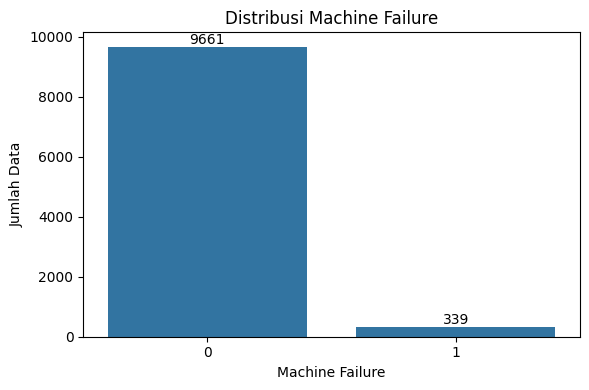

In [ ]:


plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='Machine failure',
    data=df
)

plt.title('Distribusi Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Jumlah Data')

# Menampilkan jumlah di atas setiap batang
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Interpretasi:**

Berdasarkan visualisasi, terlihat bahwa distribusi `Machine failure` sangat tidak seimbang. Kelas 0 memiliki jumlah data sebanyak 9.661 atau 96,61%, sedangkan kelas 1 hanya memiliki 339 data atau 3,39%.

Dominasi kelas 0 menunjukkan adanya **class imbalance** yang cukup tinggi. Kondisi ini perlu diperhatikan pada tahap preprocessing dan pemodelan karena model dapat lebih cenderung memprediksi kelas mayoritas dibandingkan kelas minoritas.

### Distribusi Fitur Numerik

Visualisasi distribusi fitur numerik dilakukan untuk mengetahui pola penyebaran nilai pada masing-masing variabel. Histogram digunakan untuk melihat bentuk distribusi, rentang nilai, serta pola konsentrasi data.

Fitur yang dianalisis meliputi `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, dan `Tool wear [min]`.

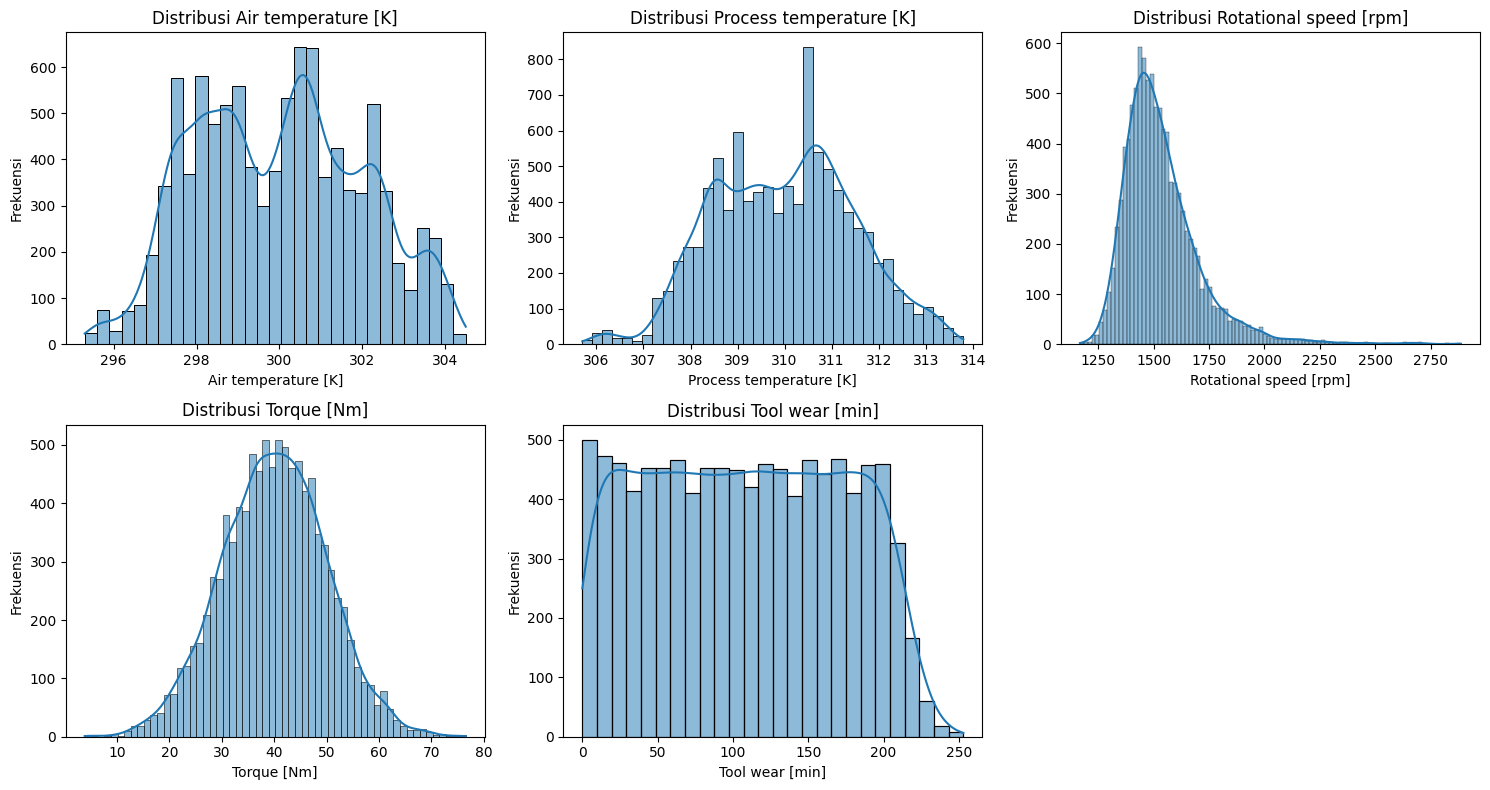

In [ ]:
# Daftar fitur numerik yang akan divisualisasikan
numeric_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Membuat histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Menghapus subplot yang tidak digunakan
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Interpretasi:**

Berdasarkan histogram, masing-masing fitur numerik memiliki pola distribusi yang berbeda. `Air temperature [K]` dan `Process temperature [K]` menunjukkan penyebaran data pada rentang suhu tertentu dengan beberapa konsentrasi nilai.

`Rotational speed [rpm]` menunjukkan distribusi yang cenderung miring ke kanan (*right-skewed*). Sebagian besar data terkonsentrasi pada nilai sekitar 1.400–1.600 rpm, sedangkan sebagian data memiliki nilai rotational speed yang lebih tinggi.

Distribusi `Torque [Nm]` relatif menyerupai distribusi normal dengan konsentrasi data berada di sekitar 40–45 Nm. Sementara itu, `Tool wear [min]` memiliki penyebaran yang relatif merata hingga sekitar 200 menit, kemudian jumlah data menurun pada nilai yang lebih tinggi.

Perbedaan pola distribusi tersebut perlu diperhatikan pada tahap preprocessing dan pemodelan, khususnya pada algoritma yang sensitif terhadap skala dan distribusi data.

### Identifikasi Outlier dengan Boxplot

Boxplot digunakan untuk melihat persebaran data dan mengidentifikasi kemungkinan adanya outlier pada fitur numerik. Outlier ditampilkan sebagai titik yang berada di luar batas whisker pada boxplot.

Visualisasi ini digunakan untuk melengkapi analisis distribusi fitur yang telah dilakukan menggunakan histogram.

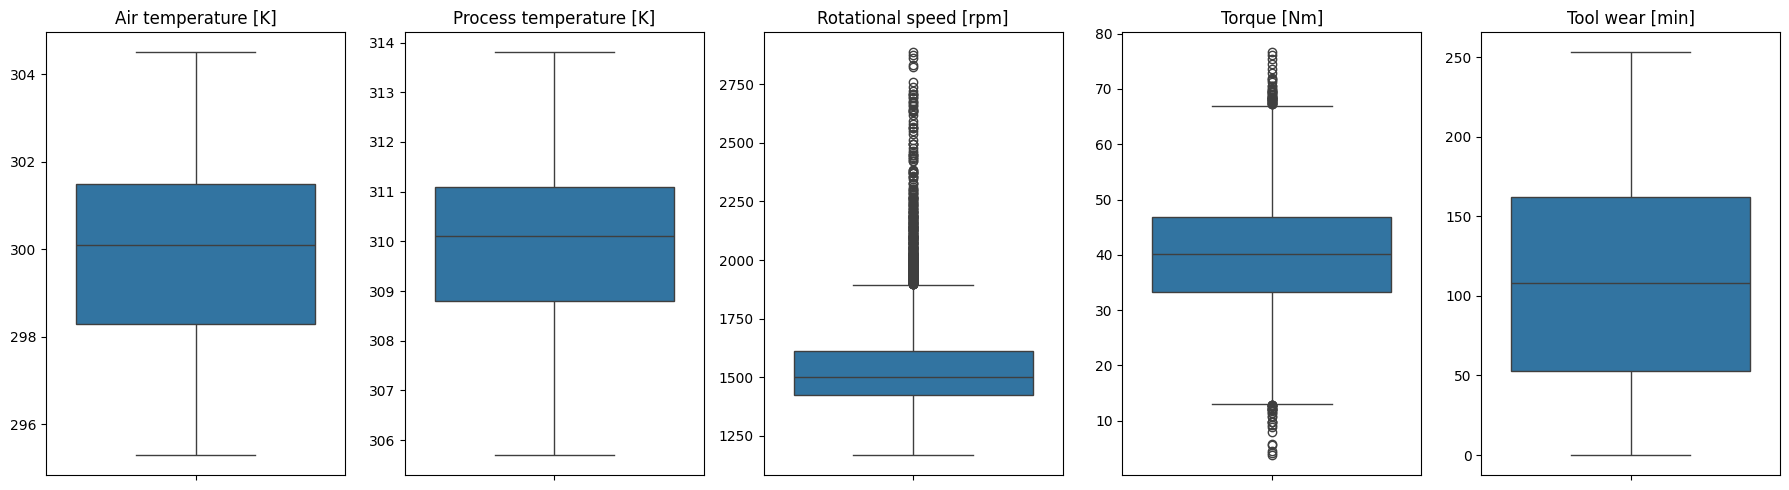

In [ ]:
# Membuat boxplot untuk setiap fitur numerik
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretasi:**

Berdasarkan boxplot, sebagian besar fitur tidak menunjukkan outlier yang mencolok. Namun, terdapat beberapa nilai yang berada di luar batas whisker pada fitur `Rotational speed [rpm]` dan `Torque [Nm]`.

Fitur `Rotational speed [rpm]` menunjukkan cukup banyak nilai di atas batas whisker, sehingga terdapat indikasi nilai ekstrem pada kecepatan rotasi yang tinggi. Sementara itu, `Torque [Nm]` juga memiliki beberapa nilai yang berada di luar batas whisker pada sisi bawah dan atas.

Pada `Air temperature [K]`, `Process temperature [K]`, dan `Tool wear [min]`, tidak terlihat titik yang berada jauh di luar whisker.

Keberadaan nilai ekstrem tersebut perlu diperhatikan pada tahap preprocessing dan pemodelan. Nilai tersebut tidak langsung dihapus karena dapat merepresentasikan kondisi operasional mesin yang sebenarnya.

### Analisis Korelasi Antarvariabel

Analisis korelasi dilakukan untuk mengetahui hubungan antarvariabel numerik dalam dataset. Korelasi digunakan untuk melihat arah dan kekuatan hubungan linear antara dua variabel.

Visualisasi korelasi menggunakan heatmap dengan nilai korelasi berada pada rentang -1 hingga 1. Nilai yang mendekati 1 menunjukkan hubungan positif yang kuat, nilai yang mendekati -1 menunjukkan hubungan negatif yang kuat, sedangkan nilai yang mendekati 0 menunjukkan hubungan linear yang lemah.

Analisis ini juga digunakan untuk melihat hubungan antara fitur numerik dengan variabel target `Machine failure`.

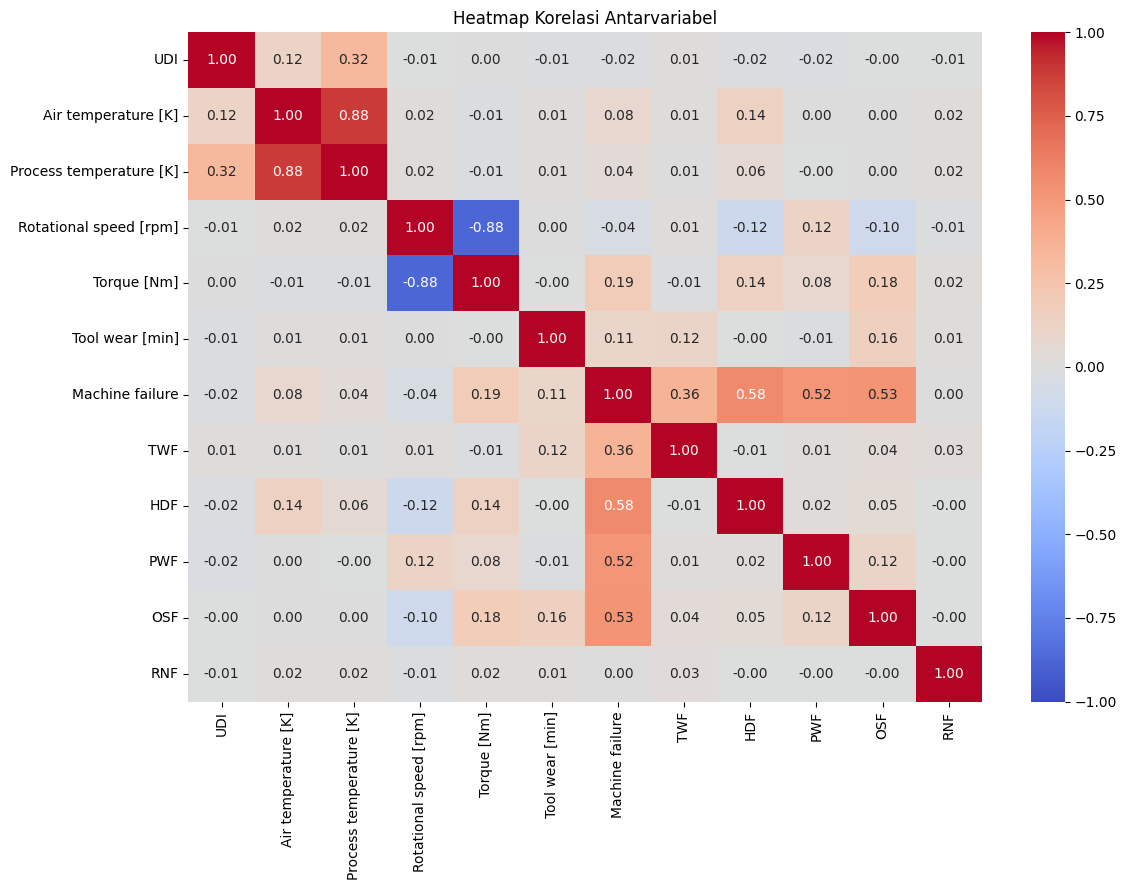

In [ ]:
# Memilih kolom numerik
numeric_data = df.select_dtypes(include=['int64', 'float64'])

# Menghitung korelasi
correlation = numeric_data.corr()

# Membuat heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Heatmap Korelasi Antarvariabel')
plt.tight_layout()
plt.show()

**Interpretasi:**

Berdasarkan heatmap korelasi, terdapat beberapa hubungan yang cukup kuat antarvariabel. `Air temperature [K]` memiliki korelasi positif yang kuat dengan `Process temperature [K]` sebesar 0,88. Hal ini menunjukkan bahwa kedua variabel tersebut memiliki hubungan linear yang kuat.

Sementara itu, `Rotational speed [rpm]` memiliki korelasi negatif yang kuat dengan `Torque [Nm]`, yaitu sebesar -0,88. Artinya, pada dataset ini peningkatan rotational speed cenderung diikuti dengan penurunan torque.

Terhadap variabel target `Machine failure`, korelasi tertinggi terdapat pada `HDF` sebesar 0,58, `OSF` sebesar 0,53, dan `PWF` sebesar 0,52. Variabel `TWF` memiliki korelasi sebesar 0,36. Sementara itu, fitur operasional seperti `Torque [Nm]` dan `Tool wear [min]` memiliki korelasi masing-masing sebesar 0,19 dan 0,11.

Hasil korelasi menunjukkan adanya hubungan antarvariabel, tetapi korelasi tidak menunjukkan hubungan sebab-akibat. Selain itu, variabel indikator kegagalan seperti `TWF`, `HDF`, `PWF`, `OSF`, dan `RNF` perlu diperhatikan pada tahap preprocessing karena dapat mengandung informasi yang berkaitan langsung dengan status kegagalan mesin.

### Analisis Fitur terhadap Machine Failure

Analisis ini dilakukan untuk melihat perbedaan distribusi fitur numerik berdasarkan status kegagalan mesin. Boxplot digunakan untuk membandingkan distribusi masing-masing fitur antara kelompok `Machine failure = 0` dan `Machine failure = 1`.

Perbandingan ini dapat memberikan gambaran awal mengenai fitur yang memiliki pola distribusi berbeda antara mesin yang mengalami kegagalan dan mesin yang tidak mengalami kegagalan.

### Kesimpulan Hasil EDA

Berdasarkan hasil Exploratory Data Analysis (EDA) pada dataset AI4I 2020 Predictive Maintenance, dataset terdiri dari 10.000 data dan 14 kolom. Seluruh kolom memiliki 10.000 nilai non-null dan tidak ditemukan data duplikat. Hasil tersebut menunjukkan bahwa dataset berada dalam kondisi lengkap dan tidak memerlukan penanganan missing value maupun penghapusan data duplikat.

Hasil statistik deskriptif menunjukkan bahwa fitur numerik memiliki rentang nilai yang berbeda. `Air temperature [K]` berada pada rentang 295,3–304,5 K, `Process temperature [K]` berada pada rentang 305,7–313,8 K, `Rotational speed [rpm]` berada pada rentang 1168–2886 rpm, `Torque [Nm]` berada pada rentang 3,8–76,6 Nm, dan `Tool wear [min]` berada pada rentang 0–253 menit.

Distribusi target `Machine failure` menunjukkan adanya class imbalance yang cukup tinggi. Sebanyak 9.661 data atau 96,61% termasuk kelas 0 (tidak terjadi kegagalan), sedangkan 339 data atau 3,39% termasuk kelas 1 (terjadi kegagalan). Kondisi ini perlu diperhatikan pada tahap preprocessing dan pemodelan.

Berdasarkan visualisasi distribusi, setiap fitur memiliki pola persebaran yang berbeda. `Rotational speed [rpm]` menunjukkan distribusi yang cenderung miring ke kanan, sedangkan `Torque [Nm]` memiliki distribusi yang relatif menyerupai distribusi normal. Hasil boxplot juga menunjukkan adanya nilai ekstrem pada beberapa fitur, terutama `Rotational speed [rpm]` dan `Torque [Nm]`.

Hasil analisis korelasi menunjukkan hubungan positif yang kuat antara `Air temperature [K]` dan `Process temperature [K]` dengan nilai korelasi 0,88, serta hubungan negatif yang kuat antara `Rotational speed [rpm]` dan `Torque [Nm]` dengan nilai korelasi -0,88. Terhadap `Machine failure`, korelasi tertinggi terdapat pada `HDF` (0,58), `OSF` (0,53), dan `PWF` (0,52).

Secara keseluruhan, hasil EDA menunjukkan bahwa dataset dapat digunakan untuk tahap preprocessing dan pemodelan machine learning. Beberapa hal yang perlu diperhatikan pada tahap selanjutnya adalah class imbalance, perbedaan skala antarfitur, keberadaan nilai ekstrem pada beberapa fitur, serta hubungan antarvariabel yang cukup kuat.

In [ ]:
# ==========================================
# 1. PEMBERSIHAN DATA (CLEANING DATA)
# ==========================================

# Cek jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah Baris Duplikat: {duplicate_count}")

# Hapus duplikat jika ada
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Data duplikat berhasil dihapus!")

# Cek missing value per kolom
missing_values = df.isnull().sum()
print("\nJumlah Missing Value per Kolom:")
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Tidak ada missing value!")

# Penanganan missing value jika ada
if df.isnull().sum().sum() > 0:
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print("Missing value berhasil ditangani!")
else:
    print("Dataset ai4i2020 sudah bersih dan utuh.")

Jumlah Baris Duplikat: 0

Jumlah Missing Value per Kolom:
Tidak ada missing value!
Dataset ai4i2020 sudah bersih dan utuh.


Pembersihan data merupakan langkah awal untuk memastikan keutuhan dataset sebelum diolah oleh model Machine Learning. Pada tahap ini dilakukan pemeriksaan keberadaan data duplikat serta nilai kosong (missing values). Baris duplikat dapat memicu kebocoran informasi (data leakage) antara data latih dan data uji, sementara nilai kosong dapat mengganggu perhitungan operasi matriks.Hasil Analisis:Data Duplikat: Ditemukan 0 data duplikat pada 10.000 sampel observasi.   Missing Value: Ditemukan 0 nilai kosong di seluruh kolom. Dataset berada dalam kondisi utuh dan bersih.


In [ ]:
# ==========================================
# 2. SELEKSI FITUR (MENGHAPUS IDENTIFIER)
# ==========================================

# Bersihkan spasi gaib pada nama kolom jika ada
df.columns = df.columns.str.strip()

# Kolom 'UDI' dan 'Product ID' adalah ID unik yang tidak relevan untuk prediksi kondisi mesin
cols_to_drop = ['UDI', 'Product ID']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

if existing_cols_to_drop:
    df_clean = df.drop(columns=existing_cols_to_drop)
    print(f"Kolom {existing_cols_to_drop} berhasil dihapus.")
else:
    df_clean = df.copy()

print("Daftar kolom setelah pembersihan ID:")
print(df_clean.columns.tolist())

Kolom ['UDI', 'Product ID'] berhasil dihapus.
Daftar kolom setelah pembersihan ID:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


Kolom UDI (indeks baris) dan Product ID merupakan identitas unik instrumen yang tidak berhubungan dengan performa fisik atau risiko kegagalan mesin. Mempertahankan kolom identifier dapat menyebabkan model mengalami overfitting atau mempelajari pola semu (spurious correlation).

Hasil Analisis:
Kolom UDI dan Product ID dieliminasi dari DataFrame sehingga fitur yang tersisa murni berupa variabel operasional mesin.


In [ ]:
# ==========================================
# 3. ENCODING VARIABEL KATEGORIKAL
# ==========================================

# Kolom 'Type' berisi kualitas produk ('L', 'M', 'H')
if 'Type' in df_clean.columns:
    print("Nilai unik kolom Type sebelum encoding:", df_clean['Type'].value_counts().to_dict())

    # Menggunakan One-Hot Encoding
    df_encoded = pd.get_dummies(df_clean, columns=['Type'], drop_first=True, dtype=int)
    print("One-Hot Encoding pada kolom 'Type' berhasil dilakukan!")
else:
    df_encoded = df_clean.copy()

print(f"Dimensi dataset setelah encoding: {df_encoded.shape}")
print("Daftar kolom akhir:")
print(df_encoded.columns.tolist())

Nilai unik kolom Type sebelum encoding: {'L': 6000, 'M': 2997, 'H': 1003}
One-Hot Encoding pada kolom 'Type' berhasil dilakukan!
Dimensi dataset setelah encoding: (10000, 13)
Daftar kolom akhir:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']


Algoritma Machine Learning memerlukan input bertipe numerik. Kolom Type merepresentasikan varian kualitas produk (L = Low, M = Medium, H = High). Untuk mengubahnya menjadi format angka tanpa mengasumsikan tingkatan urutan sembarangan, digunakan metode One-Hot Encoding via pd.get_dummies() dengan argumen drop_first=True.

Hasil Analisis:
Kolom Type dikonversi menjadi dua kolom biner baru (Type_M dan Type_H), di mana kategori L diwakili saat kedua kolom berpenilai 0.

In [ ]:
# ==========================================
# 4. PEMISAHAN FITUR (X) DAN TARGET (y)
# ==========================================

# Target utama klasifikasi biner adalah 'Machine failure' (atau 'Target')
target_col = 'Machine failure' if 'Machine failure' in df_encoded.columns else 'Target'

# Jika ada kolom mode kegagalan spesifik (TWF, HDF, PWF, OSF, RNF), kita keluarkan agar tidak membocorkan target utama
specific_failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
drop_for_X = [target_col] + [col for col in specific_failure_cols if col in df_encoded.columns]

X = df_encoded.drop(columns=drop_for_X)
y = df_encoded[target_col]

print(f"Dimensi Matriks Fitur (X): {X.shape}")
print(f"Dimensi Vektor Target (y): {y.shape}")

print("\nDistribusi Kelas Target (y):")
print(y.value_counts())

print("\nPersentase Distribusi Kelas Target (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Dimensi Matriks Fitur (X): (10000, 7)
Dimensi Vektor Target (y): (10000,)

Distribusi Kelas Target (y):
Machine failure
0    9661
1     339
Name: count, dtype: int64

Persentase Distribusi Kelas Target (%):
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


Memisahkan variabel bebas/prediktor ($X$) dari variabel target ($y$). Pada dataset ai4i2020.csv, target biner utama adalah Machine failure (1 = Mesin Gagal/Rusak, 0 = Mesin Normal).   Hasil Analisis:Matriks X: Terdiri dari 10.000 sampel dan 7 fitur prediktor (suhu, kecepatan putar, torsi, keausan alat, dan tipe produk).   Distribusi Target (y): Terdeteksi ketidakseimbangan kelas (class imbalance) yang sangat dominan, di mana 96,61% sampel berstatus normal (0) dan 3,39% berstatus gagal (1). Hal ini menjadi catatan bagi Anggota 3, 4, dan 5 untuk berfokus pada metrik Recall, F1-Score, dan AUC-ROC.

In [ ]:
# ==========================================
# 5. PEMBAGIAN DATA TRAIN & TEST (80:20)
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah Sampel Data Training (80%): {X_train.shape[0]} entri")
print(f"Jumlah Sampel Data Testing  (20%): {X_test.shape[0]} entri")

print("\nDistribusi Proporsi Target pada Data Training (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribusi Proporsi Target pada Data Testing (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Jumlah Sampel Data Training (80%): 8000 entri
Jumlah Sampel Data Testing  (20%): 2000 entri

Distribusi Proporsi Target pada Data Training (%):
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Distribusi Proporsi Target pada Data Testing (%):
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


Dataset dialokasikan dengan proporsi 80% untuk pelatihan (training) dan 20% untuk pengujian (testing). Parameter stratify=y digunakan agar rasio ketidakseimbangan kelas target (~96,6% : ~3,4%) dipertahankan secara identik pada kedua himpunan data.

Hasil Analisis:

Data Training: 8.000 entri data.

Data Testing: 2.000 entri data.

Proporsi kelas target pada subset train dan test terbukti stabil dan identik.

In [ ]:
# ==========================================
# 6. STANDARDISASI FITUR (FEATURE SCALING)
# ==========================================

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Kolom numerik kontinu pada dataset ai4i2020
numeric_features = [col for col in [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
] if col in X.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit transform pada data train, transform pada data test
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("--- Hasil Verifikasi Penyesuaian Skala ---")
print("Rata-rata (Mean) Data Training setelah scaling (Mendekati 0):")
print(X_train_scaled[numeric_features].mean(axis=0).round(4).to_dict())

print("\nSimpangan Baku (Std Dev) Data Training setelah scaling (Mendekati 1):")
print(X_train_scaled[numeric_features].std(axis=0).round(4).to_dict())

--- Hasil Verifikasi Penyesuaian Skala ---
Rata-rata (Mean) Data Training setelah scaling (Mendekati 0):
{'Air temperature [K]': 0.0, 'Process temperature [K]': 0.0, 'Rotational speed [rpm]': 0.0, 'Torque [Nm]': -0.0, 'Tool wear [min]': -0.0}

Simpangan Baku (Std Dev) Data Training setelah scaling (Mendekati 1):
{'Air temperature [K]': 1.0001, 'Process temperature [K]': 1.0001, 'Rotational speed [rpm]': 1.0001, 'Torque [Nm]': 1.0001, 'Tool wear [min]': 1.0001}


Fitur seperti Rotational speed [rpm] (skala ribuan) dan Torque [Nm] (skala puluhan) memiliki perbedaan jangkauan skala yang cukup signifikan. StandardScaler meratakan skala sehingga memiliki rata-rata ($\mu$) = 0 dan simpangan baku ($\sigma$) = 1.Proses fit_transform() dijalankan hanya pada data training, sedangkan data testing cukup di-transform() guna menghindari data leakage.Hasil Analisis:Seluruh fitur numerik kontinu kini berada pada kisaran skala terstandardisasi yang seragam.

In [ ]:
# ==========================================
# 7. RINGKASAN & VARIABEL UNTUK MODELLING
# ==========================================

print("==================================================================")
print("                     Data Siap Untuk di Train                     ")
print("==================================================================")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print(f"y_train shape        : {y_train.shape}")
print(f"y_test shape         : {y_test.shape}")
print("==================================================================")
print("Status: Seluruh data ai4i2020 bersih, terpisah, ter-scale, dan siap dilatih!")

                     Data Siap Untuk di Train                     
X_train_scaled shape : (8000, 7)
X_test_scaled shape  : (2000, 7)
y_train shape        : (8000,)
y_test shape         : (2000,)
Status: Seluruh data ai4i2020 bersih, terpisah, ter-scale, dan siap dilatih!


Rangkaian tahapan preprocessing data oleh Anggota 2 untuk dataset ai4i2020.csv telah tuntas. Empat variabel utama yang siap dipanggil langsung oleh Anggota 3, 4, dan 5:   X_train_scaled : Data latih fitur (8.000 sampel, ter-scale).X_test_scaled  : Data uji fitur (2.000 sampel, ter-scale).y_train        : Data latih target biner (8.000 label).y_test         : Data uji target biner (2.000 label).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Library siap digunakan!")

Library siap digunakan!


In [ ]:
# 1. Load data
df = pd.read_csv('ai4i2020.csv')

# 2. Hapus kolom identifier yang tidak ada hubungannya dengan machine failure
df_clean = df.drop(columns=['UDI', 'Product ID'])

# 3. Encoding kolom kategorikal 'Type' (L, M, H) menjadi angka
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

# 4. Definisikan Fitur (X) dan Target (y)
# Drop target spesifik (TWF, HDF, dll) karena kita fokus pada prediksi biner 'Machine failure'
X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']

# 5. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Feature Scaling (Wajib untuk algoritma berbasis jarak seperti KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil displit dan diskalakan!")
print("Ukuran X_train:", X_train_scaled.shape)

Data berhasil displit dan diskalakan!
Ukuran X_train: (8000, 7)


In [ ]:
# Inisialisasi model dengan max_depth=5 untuk mencegah overfitting
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# Training
dt.fit(X_train_scaled, y_train)

# Prediksi
dt_pred = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]

# Evaluasi Metrik
dt_train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
dt_test_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred, zero_division=0)
dt_rec = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_auc = roc_auc_score(y_test, dt_proba)

print("Berhasil mengeksekusi Decision Tree.")

Berhasil mengeksekusi Decision Tree.


In [ ]:
# Inisialisasi model KNN dengan nilai K=5
knn = KNeighborsClassifier(n_neighbors=5)

# Training
knn.fit(X_train_scaled, y_train)

# Prediksi
knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

# Evaluasi Metrik
knn_train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
knn_test_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred, zero_division=0)
knn_rec = recall_score(y_test, knn_pred, zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, zero_division=0)
knn_auc = roc_auc_score(y_test, knn_proba)

# Menyatukan hasil ke dalam tabel sesuai format laporan kelompok
hasil_anggota_3 = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN'],
    'Train Acc': [dt_train_acc, knn_train_acc],
    'Test Acc': [dt_test_acc, knn_test_acc],
    'Precision': [dt_prec, knn_prec],
    'Recall': [dt_rec, knn_rec],
    'F1-Score': [dt_f1, knn_f1],
    'AUC-ROC': [dt_auc, knn_auc]
}).round(4)

print("Tabel Hasil Evaluasi Bagian Modeling 1:\n")
print(hasil_anggota_3.to_string(index=False))

Tabel Hasil Evaluasi Bagian Modeling 1:

        Model  Train Acc  Test Acc  Precision  Recall  F1-Score  AUC-ROC
Decision Tree     0.9318     0.930     0.3125  0.8824    0.4615   0.9083
          KNN     0.9804     0.974     0.8333  0.2941    0.4348   0.8292


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [ ]:
# Inisialisasi model Naive Bayes
nb = GaussianNB()

# Training
nb.fit(X_train_scaled, y_train)

# Prediksi
nb_pred = nb.predict(X_test_scaled)
nb_proba = nb.predict_proba(X_test_scaled)[:, 1]

# Evaluasi Metrik
nb_train_acc = accuracy_score(y_train, nb.predict(X_train_scaled))
nb_test_acc = accuracy_score(y_test, nb_pred)
nb_prec = precision_score(y_test, nb_pred, zero_division=0)
nb_rec = recall_score(y_test, nb_pred, zero_division=0)
nb_f1 = f1_score(y_test, nb_pred, zero_division=0)
nb_auc = roc_auc_score(y_test, nb_proba)

print("Berhasil mengeksekusi Naive Bayes.")

Berhasil mengeksekusi Naive Bayes.


In [ ]:
# Inisialisasi model Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Training
lr.fit(X_train_scaled, y_train)

# Prediksi
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluasi Metrik
lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, zero_division=0)
lr_rec = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
lr_auc = roc_auc_score(y_test, lr_proba)

print("Berhasil mengeksekusi Logistic Regression.")

Berhasil mengeksekusi Logistic Regression.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# 1. Pelatihan Model Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi data uji
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = (
    rf_model.predict_proba(X_test)[:, 1]
    if hasattr(rf_model, "predict_proba")
    else y_pred_rf
)





In [ ]:
# 2. Evaluasi Metrik
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted")
rec_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

# Menghitung AUC-ROC (Menyesuaikan binary / multiclass)
try:
  if len(np.unique(y_test)) == 2:
    auc_rf = roc_auc_score(y_test, y_prob_rf)
  else:
    auc_rf = roc_auc_score(
        y_test, rf_model.predict_proba(X_test), multi_class="ovr"
    )
except Exception as e:
  auc_rf = None

print("=== Hasil Evaluasi Random Forest ===")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
if auc_rf is not None:
  print(f"AUC-ROC   : {auc_rf:.4f}")

=== Hasil Evaluasi Random Forest ===
Accuracy  : 0.9815
Precision : 0.9801
Recall    : 0.9815
F1-Score  : 0.9793
AUC-ROC   : 0.9616



=== Top 5 Fitur Terpenting ===
                Feature  Importance
            Torque [Nm]    0.325802
 Rotational speed [rpm]    0.227445
        Tool wear [min]    0.170059
    Air temperature [K]    0.133696
Process temperature [K]    0.116563


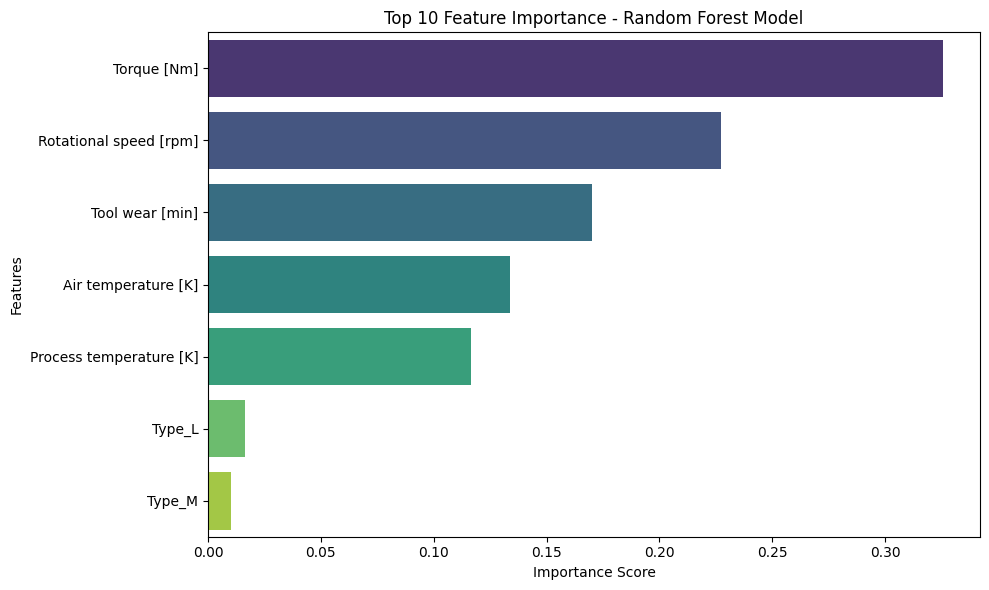

In [ ]:
# 3. Analisis Feature Importance
feature_names = (
    X_train.columns
    if hasattr(X_train, "columns")
    else [f"Feature {i}" for i in range(X_train.shape[1])]
)
importances = rf_model.feature_importances_

df_importance = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Menentukan 5 Fitur Terpenting
top_5_features = df_importance.head(5)

print("\n=== Top 5 Fitur Terpenting ===")
print(top_5_features.to_string(index=False))

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=df_importance.head(10),
    palette="viridis",
    hue="Feature",
    legend=False,
)
plt.title("Top 10 Feature Importance - Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()